In [1]:
import os
import json
import pandas as pd

directory_path = "./251029_generated_descriptions_Phi-4-mini-instruct"
data_list = []
# Iterate through all files in the directory
for filename in os.listdir(directory_path):
    if filename.endswith('.json'):
        file_path = os.path.join(directory_path, filename)
        with open(file_path, 'r', encoding='utf-8') as file:
            try:
                data = json.load(file)
                # Ensure it's a dict with 4 key-value pairs
                if isinstance(data, dict):
                    if data["data_point"] == "":
                        print(f"Skipping {filename}, data point empty")
                    
                        continue
                    data_list.append(data)
                else:
                    print(f"Skipping {filename}")
            except json.JSONDecodeError:
                print(f"Skipping {filename}: invalid JSON format.")
                
# Convert list of dicts to DataFrame
df = pd.DataFrame(data_list)
df.tail()

,question,original_source,data_group,data_point,reference_1,reference_2,description,references
2005,What is the meaning of eco-toxicity in relatio...,CPR 2024.pdf,essential environmental characteristics,eco-toxicity,CPR 2024.pdf,Circularise 2025.pdf,Eco-toxicity refers to the potential harm caus...,[{'text': 'ANNEX II Predeter mined environment...
2006,What is the meaning of freshwater in relation ...,CPR 2024.pdf,essential environmental characteristics,freshwater,CPR 2024.pdf,Circularise 2025.pdf,"Freshwater refers to water bodies like rivers,...",[{'text': 'ANNEX II Predeter mined environment...
2007,What is the meaning of human toxicity cancerog...,CPR 2024.pdf,essential environmental characteristics,human toxicity cancerogenic,CPR 2024.pdf,Circularise 2025.pdf,Human toxicity cancerogenic refers to substanc...,[{'text': 'ANNEX II Predeter mined environment...
2008,What is the meaning of human toxicity non-canc...,CPR 2024.pdf,essential environmental characteristics,human toxicity non-cancerogenic,CPR 2024.pdf,Circularise 2025.pdf,Human toxicity non-cancerogenic refers to subs...,[{'text': 'ANNEX II Predeter mined environment...
2009,What is the meaning of land use related impact...,CPR 2024.pdf,essential environmental characteristics,land use related impacts,CPR 2024.pdf,Kebede 2024.pdf,Land use related impacts refer to the environ...,[{'text': 'ANNEX II Predeter mined environment...


In [2]:
import pandas as pd

initial_groups_df = pd.read_excel('./data/251027 input data points and groups.xlsx')
initial_groups_df['Data_groups'] = initial_groups_df['Data_groups']\
    .str.strip().str.lower().str.replace('&', 'and')
initial_groups_df.head()

,Data_groups,Data_points,Source,File,Passport_type
0,general information,"Product commercial name, Manufacturer's name, ...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport
1,material health,"Security information, warnings, recommendation...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport
2,sustainability,"Environmental declaration, Life cycle assessme...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport
3,design and production,"Manufacturing process, Manufacturing technique...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport
4,use and operate phase,"Positioning in the building, location in the b...",Munaro and Tavares 2020,Munaro and Tavares 2021.pdf,Material passport


In [3]:
passport_type_map = {}
for i in range(initial_groups_df.shape[0]):
    document = initial_groups_df.iloc[i].File
    passport = initial_groups_df.iloc[i].Passport_type

    passport_type_map[document] = passport

passport_type_map

{'Munaro and Tavares 2021.pdf': 'Material passport',
 'Giovanardi 2023.pdf': 'Digital passport',
 'Çetin 2023.pdf': 'Material passport',
 'Kebede 2024.pdf': 'Digital product passport',
 'Atta 2021.pdf': 'Material passport',
 'Göswein 2022.pdf': 'Material passport',
 'Heisel and Rau-Oberhuber 2020.pdf': 'Material passport',
 'Honic 2019.pdf': 'Material passport',
 'Honic 2021.pdf': 'Material passport',
 'Mulhall 2022.pdf': 'Product Circularity Data Sheet',
 'BAMB 2019.pdf': 'Material passport',
 'Platform CB 2023.pdf': 'Material passport',
 'Bauen digital Schweiz 2024.pdf': 'Digital product passport',
 'Bosma 2024.pdf': 'Digital product passport',
 'Mao and Cao 2025.pdf': 'Material passport',
 'Markou 2025.pdf': 'Material passport',
 'Wan and Jiang 2025.pdf': 'Digital product passport',
 'Byers 2025.pdf': 'Material passport',
 'ISO 59040 2025.pdf': 'Product Circularity Data Sheet',
 'Seddiqui 2024.pdf': 'Material passport',
 'Van Capelleveen 2023.pdf': 'Digital passport',
 'KC 2024.pdf'

In [4]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from sentence_transformers import SentenceTransformer


model = SentenceTransformer('BAAI/bge-m3')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

#### Clustering using descriptions

In [5]:
description_embeddings = model.encode(df["description"])

In [13]:
# Read CSV file
df_descriptions_phi = pd.read_csv('02_251215_clusterdata_descriptions_Phi-4-mini.csv')

descriptions_trials_data = df_descriptions_phi[((df_descriptions_phi['user_attrs_dbcv_score'] > 0.6) & (df_descriptions_phi['user_attrs_ccc_score'] > 0.6) & 
                     (df_descriptions_phi['user_attrs_n_clusters'] > 3) & (df_descriptions_phi['user_attrs_n_clusters'] < 50))].sort_values (['user_attrs_n_clusters','values_0','values_1'])

In [14]:
descriptions_trials_data

,number,values_0,values_1,params_min_cluster_size,params_min_samples,params_n_components,params_n_neighbors,user_attrs_ccc_score,user_attrs_dbcv_score,user_attrs_n_clusters,user_attrs_outlier_ratio
112,112,0.646905,0.693928,17,19,12,16,0.693928,0.646905,22,0.245274
36,36,0.654794,0.636646,9,18,15,28,0.636646,0.654794,24,0.247761
211,211,0.654794,0.636646,9,18,15,28,0.636646,0.654794,24,0.247761
272,272,0.613186,0.677216,9,19,5,25,0.677216,0.613186,26,0.277114
208,208,0.607853,0.632169,7,18,5,18,0.632169,0.607853,28,0.247761
225,225,0.642769,0.600426,9,18,11,6,0.600426,0.642769,30,0.236816
151,151,0.616576,0.793220,14,18,2,15,0.793220,0.616576,31,0.326368
259,259,0.601448,0.779366,9,19,2,17,0.779366,0.601448,34,0.320896
252,252,0.612980,0.806608,8,16,5,26,0.806608,0.612980,35,0.289552
89,89,0.603727,0.749849,7,15,7,17,0.749849,0.603727,37,0.273632


In [15]:
def get_trial_description(trials, trial_number):
    trial = trials.iloc[trial_number]

    fig_title = (
        f"Phi 4 mini Instruct descritpions, Trial {trial['number']}<br>"
        f"Params: n_neighbors={trial['params_n_neighbors']}, n_components={trial['params_n_components']}, "
        f"min_cluster_size={trial['params_min_cluster_size']}, min_samples={trial['params_min_samples']}<br>"
        f"Metrics: DBCV={trial['user_attrs_dbcv_score']:.3f}, CCC={trial['user_attrs_ccc_score']:.3f}, "
        f"Outlier Ratio={trial['user_attrs_outlier_ratio']:.3f}, Clusters={trial['user_attrs_n_clusters']}"
    )

    return fig_title

get_trial_description(descriptions_trials_data, 0)

'Phi 4 mini Instruct descritpions, Trial 112.0<br>Params: n_neighbors=16.0, n_components=12.0, min_cluster_size=17.0, min_samples=19.0<br>Metrics: DBCV=0.647, CCC=0.694, Outlier Ratio=0.245, Clusters=22.0'

In [16]:
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def extract_topic_lists(group):
    """Return grouped lists for data_group, data_point, and description."""
    topic_dict = {}
    topic_dict["topic"] = group.iloc[0]["description_topic"]
    topic_name_original = group.iloc[0]["description_topic_name"]
    
    data_point_names = []
    data_point_descriptions = []

    for i in range(group.shape[0]):
        data_point_names.append(group.iloc[i]["data_point"])
        data_point_descriptions.append(group.iloc[i]["description"])
    

    # Get embeddings for each term
    term_embeddings = model.encode(data_point_names)
    
    # dot = cosine_similarity(term_embeddings, description_topic_model.topic_embeddings_[topic_dict["topic"]].reshape(-1, 1).T)
    
    # best_idx = dot.argmax()
    # best_term = data_point_names[best_idx]
    
    # # Compute the centroid
    centroid = np.mean(term_embeddings, axis=0).reshape(1, -1)

    # original_topic_name = ' '.join([v for v in description_topic_model.get_topic_info(topic_dict["topic"]).Representation[:4]][0])
    #' '.join([word for word in description_topic_model.get_topic_info(topic_dict["topic"]).Name[0].split("_")[1:]])
    # centroid = model.encode(original_topic_name).reshape(-1, 1).T
    
    sims = cosine_similarity(centroid, term_embeddings)[0]
    sorted_ids = np.argsort(sims)[::-1]
    best_idx = sorted_ids[0]#np.argmax(sims)
    best_term = data_point_names[best_idx]
    

    topic_dict["data_points"] = []
    topic_dict["references"] = []
    topic_dict["passports"] = []

    data_point_names_sorted = []
    
    for i in sorted_ids:#range(group.shape[0]):
        data_point = {}
        data_point["data_group"] = group.iloc[i]["data_group"]
        data_point["data_point"] = group.iloc[i]["data_point"]
        data_point["description"] = group.iloc[i]["description"]
        data_point["original_source"] = group.iloc[i]["original_source"]
        data_point["reference_1"] = group.iloc[i]["reference_1"]
        data_point["reference_2"] = group.iloc[i]["reference_2"]
        
        topic_dict["data_points"].append(data_point)
        #topic_dict["references"].append(group.iloc[i]["original_source"])
        topic_dict["references"].append(group.iloc[i]["reference_1"])
        topic_dict["passports"].append(passport_type_map[group.iloc[i]["reference_1"]])
        #topic_dict["references"].append(group.iloc[i]["reference_2"])

        data_point_names_sorted.append(group.iloc[i]["data_point"])


    if "contain" and "given" in topic_name_original:
        best_term = topic_name_original
        
    print(best_term)
    print(data_point_names_sorted[:30])
    print("---------------------------")
    topic_dict["topic_label"] = best_term
    topic_dict["topic_description"] = data_point_descriptions[best_idx]


    return topic_dict


In [17]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer
import hdbscan
from hdbscan import HDBSCAN
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from bertopic.dimensionality import BaseDimensionalityReduction
import copy
from scipy.cluster import hierarchy as sch
from sentence_transformers import SentenceTransformer, util
import numpy as np

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

def create_topic_model(docs, embeddings, n_neighbors, n_components, min_cluster_size, min_samples, ctfidf_model):
    umap_model = UMAP(n_neighbors=n_neighbors,
                      n_components=n_components,
                      metric="cosine",
                      min_dist=0.0,
                      random_state=42,  # ensures deterministic embedding
                      n_jobs=1,
                      )

    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                min_samples=min_samples,
                                cluster_selection_epsilon=0.0,
                                metric="euclidean",  
                                cluster_selection_method='eom'
        )
    
    topic_model = BERTopic(verbose=True, 
                                       hdbscan_model=clusterer,
                                       vectorizer_model=CountVectorizer(stop_words='english'),
                                       ctfidf_model=ctfidf_model, 
                                       umap_model=umap_model,
                                       calculate_probabilities=False
                                       )
                
    
    topic_model.fit(docs, embeddings)

    return topic_model

In [18]:
import numpy as np
import pandas as pd
import logging
from collections.abc import Iterable
from scipy.sparse import csr_matrix
from scipy.spatial.distance import squareform
from typing import Optional, Union, Tuple


def select_topic_representation(
    ctfidf_embeddings,
    embeddings,
    use_ctfidf: bool = True,
    output_ndarray: bool = False,
):
    """Select the topic representation.

    Arguments:
        ctfidf_embeddings: The c-TF-IDF embedding matrix
        embeddings: The topic embedding matrix
        use_ctfidf: Whether to use the c-TF-IDF representation. If False, topics embedding representation is used, if it
                    exists. Default is True.
        output_ndarray: Whether to convert the selected representation into ndarray
    Raises
        ValueError:
            - If no topic representation was found
            - If c-TF-IDF embeddings are not a numpy array or a scipy.sparse.csr_matrix

    Returns:
        The selected topic representation and a boolean indicating whether it is c-TF-IDF.
    """

    def to_ndarray(array: Union[np.ndarray, csr_matrix]) -> np.ndarray:
        if isinstance(array, csr_matrix):
            return array.toarray()
        return array
    if use_ctfidf:
        if ctfidf_embeddings is None:
            repr_, ctfidf_used = embeddings, False
        else:
            repr_, ctfidf_used = ctfidf_embeddings, True
    else:
        if embeddings is None:
            repr_, ctfidf_used = ctfidf_embeddings, True
        else:
            repr_, ctfidf_used = embeddings, False

    return to_ndarray(repr_) if output_ndarray else repr_, ctfidf_used

In [19]:
def validate_distance_matrix(X, n_samples):
    """Validate the distance matrix and convert it to a condensed distance matrix
    if necessary.

    A valid distance matrix is either a square matrix of shape (n_samples, n_samples)
    with zeros on the diagonal and non-negative values or condensed distance matrix
    of shape (n_samples * (n_samples - 1) / 2,) containing the upper triangular of the
    distance matrix.

    Arguments:
        X: Distance matrix to validate.
        n_samples: Number of samples in the dataset.

    Returns:
        X: Validated distance matrix.

    Raises:
        ValueError: If the distance matrix is not valid.
    """
    # Make sure it is the 1-D condensed distance matrix with zeros on the diagonal
    s = X.shape
    if len(s) == 1:
        # check it has correct size
        n = s[0]
        if n != (n_samples * (n_samples - 1) / 2):
            raise ValueError("The condensed distance matrix must have " "shape (n*(n-1)/2,).")
    elif len(s) == 2:
        # check it has correct size
        if (s[0] != n_samples) or (s[1] != n_samples):
            raise ValueError("The distance matrix must be of shape " "(n, n) where n is the number of samples.")
        # force zero diagonal and convert to condensed
        np.fill_diagonal(X, 0)
        X = squareform(X)
    else:
        raise ValueError(
            "The distance matrix must be either a 1-D condensed "
            "distance matrix of shape (n*(n-1)/2,) or a "
            "2-D square distance matrix of shape (n, n)."
            "where n is the number of documents."
            "Got a distance matrix of shape %s" % str(s)
        )

    # Make sure its entries are non-negative
    if np.any(X < 0):
        raise ValueError("Distance matrix cannot contain negative values.")

    return X

In [20]:

color_map = {
    'C0': 'rgb(0,116,217)', 
    'C1': 'rgb(61,153,112)', 
    'C2': 'rgb(255,65,54)', 
    'C3': 'rgb(35,205,205)', 
    'C4': 'rgb(133,20,75)',
    'C5': 'rgb(255,220,0)', 
    'C6': 'rgb(40,35,35)', 
    'C7': 'rgb(61,153,112)', 
    'C8': 'rgb(255,65,54)', 
    'C9': 'rgb(35,205,205)'
}

# "rgb(0,116,217)",  # blue
# "rgb(35,205,205)",  # cyan
# "rgb(61,153,112)",  # green
# "rgb(40,35,35)",  # black
# "rgb(133,20,75)",  # magenta
# "rgb(255,65,54)",  # red
# "rgb(255,255,255)",  # white
# "rgb(255,220,0)",  # yellow

# --- Prepare reference data ---
main_references = [
    'ISO 59040 2025.pdf', 'BAMB 2019.pdf',
    'ESPR 2024.pdf', 'CPR 2024.pdf', 
    'Platform CB 2023.pdf'
]

In [21]:
int(descriptions_trials_data.iloc[0]['params_n_neighbors'])

16

In [22]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import OpenAI
from bertopic.vectorizers import ClassTfidfTransformer
import hdbscan
from hdbscan import HDBSCAN
from umap import UMAP
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from bertopic.dimensionality import BaseDimensionalityReduction
import copy
from scipy.cluster import hierarchy as sch
from sentence_transformers import SentenceTransformer, util
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from collections import Counter
from plotly.subplots import make_subplots
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
from scipy.cluster.hierarchy import linkage, to_tree


def build_tree_dict(node):
    if node.is_leaf():
        return {
            "0_topic_id": node.id,
            "1_topic_name": str(description_topic_model.get_topic_info().CustomName[description_topic_model.get_topic_info().Topic.astype(int) == node.id].iloc[0]),
            "2_data_points": list(set([p['data_point'] + " (" + p['original_source'] + ")" for p in data_points_per_description_topic[node.id + 1]['data_points']]))
        }
    return {
        "0_topic_id": node.id,
        "1_topic_name": str(hierarchical_topics.Parent_Name[hierarchical_topics.Parent_ID.astype(int) == node.id].iloc[0]),
        "2_children": [build_tree_dict(node.left),build_tree_dict(node.right)]
    }

    


ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

completed = []

for i in range(len(descriptions_trials_data)):    
    description_topic_model = create_topic_model(docs=df["description"], 
                                                 embeddings=description_embeddings, 
                                                 n_neighbors=int(descriptions_trials_data.iloc[i]['params_n_neighbors']), 
                                                 n_components=int(descriptions_trials_data.iloc[i]['params_n_components']), 
                                                 min_cluster_size=int(descriptions_trials_data.iloc[i]['params_min_cluster_size']), 
                                                 min_samples=int(descriptions_trials_data.iloc[i]['params_min_samples']),
                                                 ctfidf_model=ctfidf_model)
    


    df_copy = copy.deepcopy(df)
    df_copy["description_topic"] = ""
    df_copy["description_topic"] = description_topic_model.get_document_info(df_copy["description"]).Topic
    df_copy["description_topic_name"] = description_topic_model.get_document_info(df_copy["description"]).Name

    data_points_per_description_topic = (
    df_copy.groupby("description_topic")
      .apply(extract_topic_lists)
      .tolist()
    )


    label_per_description_topic = [f"{str(data_points['topic'])}: {data_points['topic_label']}" 
                                   for data_points in data_points_per_description_topic]

    description_topic_model.set_topic_labels(label_per_description_topic)

    # Hierarchical topics
    linkage_function = lambda x: sch.linkage(x, "ward", optimal_ordering=True)
    _distance_function = lambda x: 1 - cosine_similarity(x)
    
    hierarchical_topics = description_topic_model.hierarchical_topics(df["description"], 
                                                                      linkage_function=linkage_function, 
                                                                      distance_function=_distance_function, 
                                                                      use_ctfidf=True)
    # Select embeddings
    all_topics = sorted(list(description_topic_model.get_topics().keys()))
    topics = sorted(description_topic_model.get_topic_freq().Topic.to_list())
    indices = np.array([all_topics.index(topic) for topic in topics if topic != -1])

    # Select topic embeddings
    use_ctfidf = True

    # Calculate distance
    embeddings = select_topic_representation(description_topic_model.c_tf_idf_, description_topic_model.topic_embeddings_, use_ctfidf)[0][
        description_topic_model._outliers :
    ]
    distance_function = lambda x: validate_distance_matrix(_distance_function(x), embeddings.shape[0])
    
    X = distance_function(embeddings)
    linkage_matrix = linkage_function(X)

    
    # Choose a threshold as a fraction of the max distance
    color_threshold = 0.9

    P = sch.dendrogram(
        linkage_matrix,
        orientation="left",
        labels=label_per_description_topic[description_topic_model._outliers:],
        no_plot=True,
        color_threshold=color_threshold,
    )
    icoord = np.array(P["icoord"])
    dcoord = np.array(P["dcoord"])
    ordered_labels = np.array(P["ivl"])
    color_list = np.array(P["leaves_color_list"])

    
    color_list_dict = {}
    for label, color in zip (ordered_labels, color_list):
        color_list_dict[label] = color_map[str(color)]


    fig_title = get_trial_description(descriptions_trials_data, i)

    # --- Generate BERTopic hierarchy figure ---
    fig_hierarchy = description_topic_model.visualize_hierarchy(
        linkage_function=linkage_function,
        hierarchical_topics=hierarchical_topics,
        distance_function=distance_function,
        custom_labels=True,
        color_threshold=0.9,
        use_ctfidf=True
    )
    
    # Define a mapping from topic label -> custom hover text
    custom_hover_map = {}
    for v, k in zip(data_points_per_description_topic, label_per_description_topic):
        other_data_points = []
        for point in v['data_points']:
            if point['data_point'] in other_data_points:
                continue
            other_data_points.append(point['data_point'])
        
        custom_hover_map[k] = ";<br>".join(other_data_points[1:6])
    
    fig_hierarchy.update_layout(
        hoverlabel=dict(
            align='left',   # moves text inside hover box to the right
            bgcolor="white",
            font_size=12,
            font_family="Arial"
        )
    )
    
    for trace in fig_hierarchy.data:
        if hasattr(trace, "text") and trace.text is not None:
            trace.hovertext = [
                f"<span style='display:inline-block; width:100px'></span>{custom_hover_map.get(t, t)}"
                for t in trace.text
            ]
    
    fig_hierarchy.update_layout(
        title=dict(text=fig_title, xanchor='center', yanchor='top', font=dict(size=11, color="Black")),
        font=dict(family="Arial", size=15)
    )
    
    # --- Create combined figure layout ---
    fig_combined = make_subplots(
        rows=1, cols=2,
        shared_xaxes=False,
        shared_yaxes=False,   # Better control with categoryarray later
        column_widths=[0.4, 0.3],
        horizontal_spacing=0.3,   # space between columns (default 0.02)
        subplot_titles=("Topic Hierarchy", "Reference Distribution per Topic"),
        specs=[[{"type": "xy"}, {"type": "bar"}]]
    )
    
    # --- Extract topic order from hierarchy ---
    yaxis_hierarchy = fig_hierarchy.layout.yaxis
    topic_order = list(yaxis_hierarchy.ticktext) if hasattr(yaxis_hierarchy, "ticktext") else []
    topic_order = topic_order[::-1]
    # --- Add hierarchy traces to combined figure ---
    for trace in fig_hierarchy.data:
        trace.showlegend = False
        fig_combined.add_trace(trace, row=1, col=1)
    
    all_references_count = {}
    all_passports_count = {}
    for items, label in zip(data_points_per_description_topic[1:], label_per_description_topic[1:]):  # skip first
        topic_name = label.split(";")[0]
        all_references_count[topic_name] = Counter(items["references"])
        all_passports_count[topic_name] = Counter(items["passports"])
    
    # Experimental
    # all_references_count = all_passports_count
    # main_references = ['Material passport',
    #                 'Digital product passport',
    #                 'Digital passport',
    #                 'Product Circularity Data Sheet']
    # items = main_references
    # --- Define color map ---
    
    items = ["other"] + main_references
    colors = [
        '#A6A6A6', '#ff8370', '#00b1b0', '#fec84d', '#e42256',
        '#8088b8', '#284B70', '#405743', '#857B62', '#737781'
    ]
    model_color_map = {item: color for item, color in zip(items, colors)}
    
    # --- Flatten reference  data into DataFrame ---
    rows = []
    for topic, counter in all_references_count.items():
        other_count = 0
        for doc, count in counter.items():
            if doc in main_references:
                rows.append({'Topic': topic, 'Document': doc, 'Count': count})
            else:
                other_count += count
        if other_count > 0:
            rows.append({'Topic': topic, 'Document': "other", 'Count': other_count})
    
    df_counter = pd.DataFrame(rows)
    

    
    # --- Sync axes between subplots ---
    # Get numeric y positions from hierarchy
    y_tickvals = getattr(yaxis_hierarchy, "tickvals", None)
    y_ticktext = getattr(yaxis_hierarchy, "ticktext", topic_order)
    
    if y_tickvals is None:
        # fallback: evenly spaced ticks
        y_tickvals = list(range(len(topic_order)))
        y_ticktext = topic_order
    
    # Reverse order so top-down matches visual hierarchy
    y_tickvals = y_tickvals[::-1]
    y_ticktext = y_ticktext[::-1]
    
    # --- Rebuild subplot 2 bars using numeric y coordinates ---

    show_legend = False
    legend_shown = False
    for topic, y_val in zip(topic_order, y_tickvals):
        subset = df_counter[df_counter['Topic'] == topic].sort_values('Count', ascending=False)
        if show_legend == False and legend_shown==False:
            show_legend = len(set([row['Document'] for _, row in subset.iterrows()])) == len(main_references) + 1
            
        for _, row in subset.iterrows():
            fig_combined.add_trace(
                go.Bar(
                    y=[y_val],
                    x=[row['Count']],
                    orientation='h',
                    name=row['Document'],
                    marker_color=model_color_map.get(row['Document'], '#CCCCCC'),
                    showlegend=show_legend  # avoid duplicates
                ),
                row=1, col=2
            )
        if show_legend: 
            legend_shown = True
            show_legend = False
    
    
    # --- Force both subplots to share same y-scale and tick labels ---
    for col in [1, 2]:
        fig_combined.update_yaxes(
            tickvals=y_tickvals,
            ticktext=y_ticktext,
            range=[min(y_tickvals), max(y_tickvals)],
            autorange=False,
            showgrid=False,
            gridcolor="lightgrey",
            row=1, col=col
        )
    
    # Move left subplot's y-axis labels to the right side for visual balance
    fig_combined.update_yaxes(side="left", row=1, col=1)
    
    y_min, y_max = min(y_tickvals), max(y_tickvals)
    padding = 3
    
    fig_combined.update_yaxes(
        range=[y_min - padding, y_max + padding],  # extend top and bottom
        row=1, col=1
    )
    fig_combined.update_yaxes(
        range=[y_min - padding, y_max + padding],
        row=1, col=2
    )
    
    # Create colored tick labels using HTML <span style='color:...'>
    y_ticktext_colored = [
        f"<span style='color:{color_list_dict[t]}'>{t}</span>" for t in topic_order
    ]
    
    # Apply to subplot 2
    fig_combined.update_yaxes(
        ticktext=y_ticktext_colored,
        row=1, col=2
    )
    
    # --- Final layout ---
    fig_combined.update_layout(
        barmode='stack',
        title=dict(
            text=fig_title,
            x=0.5,
            y=0.97,
            xanchor='center',
            yanchor='top',
            font=dict(size=18)
        ),
        margin=dict(t=120, l=50, r=50, b=50),
        height=fig_hierarchy.layout.height + 100,
    )
    

    # --- Save to HTML ---
    output_path = f"./results/Phi-4-mini/251217_Phi-4-mini-combined_plot_{i}_references.html"
    fig_combined.write_html(output_path)

    df_copy.groupby("description_topic_name").apply(
        lambda x: "; ".join(x["data_point"] + " (" + x["original_source"] + ")")).to_excel(
        f"./results/Phi-4-mini/251113_grouped_datapoints_trial{int(descriptions_trials_data.iloc[i]['number'])}.xlsx", index=True)



    root, nodes = to_tree(linkage_matrix, rd=True)  
    tree_dict = build_tree_dict(root)
    with open(f"./results/Phi-4-mini/251217_grouped_datapoints_trial_{int(descriptions_trials_data.iloc[i]['number'])}_Phi-4-mini.json", "w") as f:
        json.dump(tree_dict, f, indent=4)

    



    
    


2025-12-17 12:01:50,461 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-17 12:02:06,776 - BERTopic - Dimensionality - Completed ✓
2025-12-17 12:02:06,777 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-17 12:02:06,845 - BERTopic - Cluster - Completed ✓
2025-12-17 12:02:06,849 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-17 12:02:07,030 - BERTopic - Representation - Completed ✓


recycled material
['recycled material', 'material information', 'material usage', 'materials', 'reused material', 'reused material', 'material', 'reusability', 'presence of  renewable materials', 'presence of recycled materials', 'material quality', 'reusing', 'durability', 'durability', 'durability', 'durability', 'durability', 'information on material reuse', 'recycling', 'material type', 'renewability', 'replacement of materials', 'presence of reused parts', 'use of easily recyclable materials', 'location of materials on site', 'maintenance information', 'safety', 'safety', 'recycled or reused content', 'disposed material']
---------------------------
manufacturer's name
["manufacturer's name", "manufacturer's name", "manufacturer's name", "manufacturer's name", 'manufacturer’s name', 'manufacturer information', 'manufacturer information', 'manufacturer information', 'product number', 'product number', 'product number', 'product number', 'supplier’s name', 'manufacturer', 'manufactu

/scratch/tmp.51984529.svangelova/ipykernel_101128/1605978150.py:63: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

100%|██████████| 21/21 [00:00<00:00, 353.35it/s]
/scratch/tmp.51984529.svangelova/ipykernel_101128/1605978150.py:321: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

2025-12-17 12:02:11,189 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-17 12:02:22,378 - BERTo

recycled material
['recycled material', 'recycled material', 'material information', 'materials', 'reused material', 'reused material', 'material', 'reusability', 'presence of recycled materials', 'material quality', 'quality of material', 'presence of  renewable materials', 'information on material reuse', 'recycling', 'durability', 'durability', 'durability', 'durability', 'durability', 'replacement of materials', 'material type', 'material sorting', 'presence of reused parts', 'maintenance information', 'recycled or reused content', 'disposed material', 'usage', 'refurbishment information', 'handling information', 'waste processing']
---------------------------
manufacturer's name
["manufacturer's name", "manufacturer's name", "manufacturer's name", "manufacturer's name", 'manufacturer’s name', 'manufacturer information', 'manufacturer information', 'manufacturer information', 'product number', 'product number', 'product number', 'product number', 'supplier’s name', 'manufacturer', 

/scratch/tmp.51984529.svangelova/ipykernel_101128/1605978150.py:63: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

100%|██████████| 23/23 [00:00<00:00, 395.23it/s]
/scratch/tmp.51984529.svangelova/ipykernel_101128/1605978150.py:321: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

2025-12-17 12:02:26,286 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-17 12:02:37,495 - BERTo

...

/scratch/tmp.51984529.svangelova/ipykernel_101128/1605978150.py:63: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

100%|██████████| 36/36 [00:00<00:00, 391.56it/s]
/scratch/tmp.51984529.svangelova/ipykernel_101128/1605978150.py:321: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

2025-12-17 12:04:15,136 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-17 12:04:23,649 - BERTo

recycled material
['recycled material', 'material', 'material usage', 'material quality', 'reused material', 'reused material', 'quality of material', 'material quantity', 'recycling', 'material type', 'information on use', 'renewability', 'energy consumption', 'usage', 'safety', 'disposed material', 'presence of reused parts', 'quality', 'quality', 'use of easily recyclable materials', 'recycled or reused content', 'renewable', 'renewable', 'renewable', 'renewable', 'quantity', 'quantity', 'quantity', 'quantity', 'quantity']
---------------------------
availability of spare parts
['availability of spare parts', 'availability of spare parts', 'availability of spare parts', 'availability of spare parts', 'availability of spare parts', 'availability of spare parts', 'availability of spare parts for the repair of the product', 'compatibility of components', 'compatibility with commonly available spare parts', 'available spare parts', 'compatibility', 'spare parts information', 'spare part

/scratch/tmp.51984529.svangelova/ipykernel_101128/1605978150.py:63: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



density
['density', 'density', 'density', 'density', 'density', 'density', 'density', 'density', 'density', 'density', 'density', 'porosity', 'concentration', 'specific weight']
---------------------------


100%|██████████| 44/44 [00:00<00:00, 403.51it/s]
/scratch/tmp.51984529.svangelova/ipykernel_101128/1605978150.py:321: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [23]:
 df_copy.groupby("description_topic_name").apply(
        lambda x: "; ".join(x["data_point"] + " (" + x["original_source"] + ")")).to_excel(
        f"./results/Phi-4-mini/251217_grouped_datapoints_trial{int(descriptions_trials_data.iloc[i]['number'])}.xlsx", index=True)



/scratch/tmp.51984529.svangelova/ipykernel_101128/3685983591.py:1: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



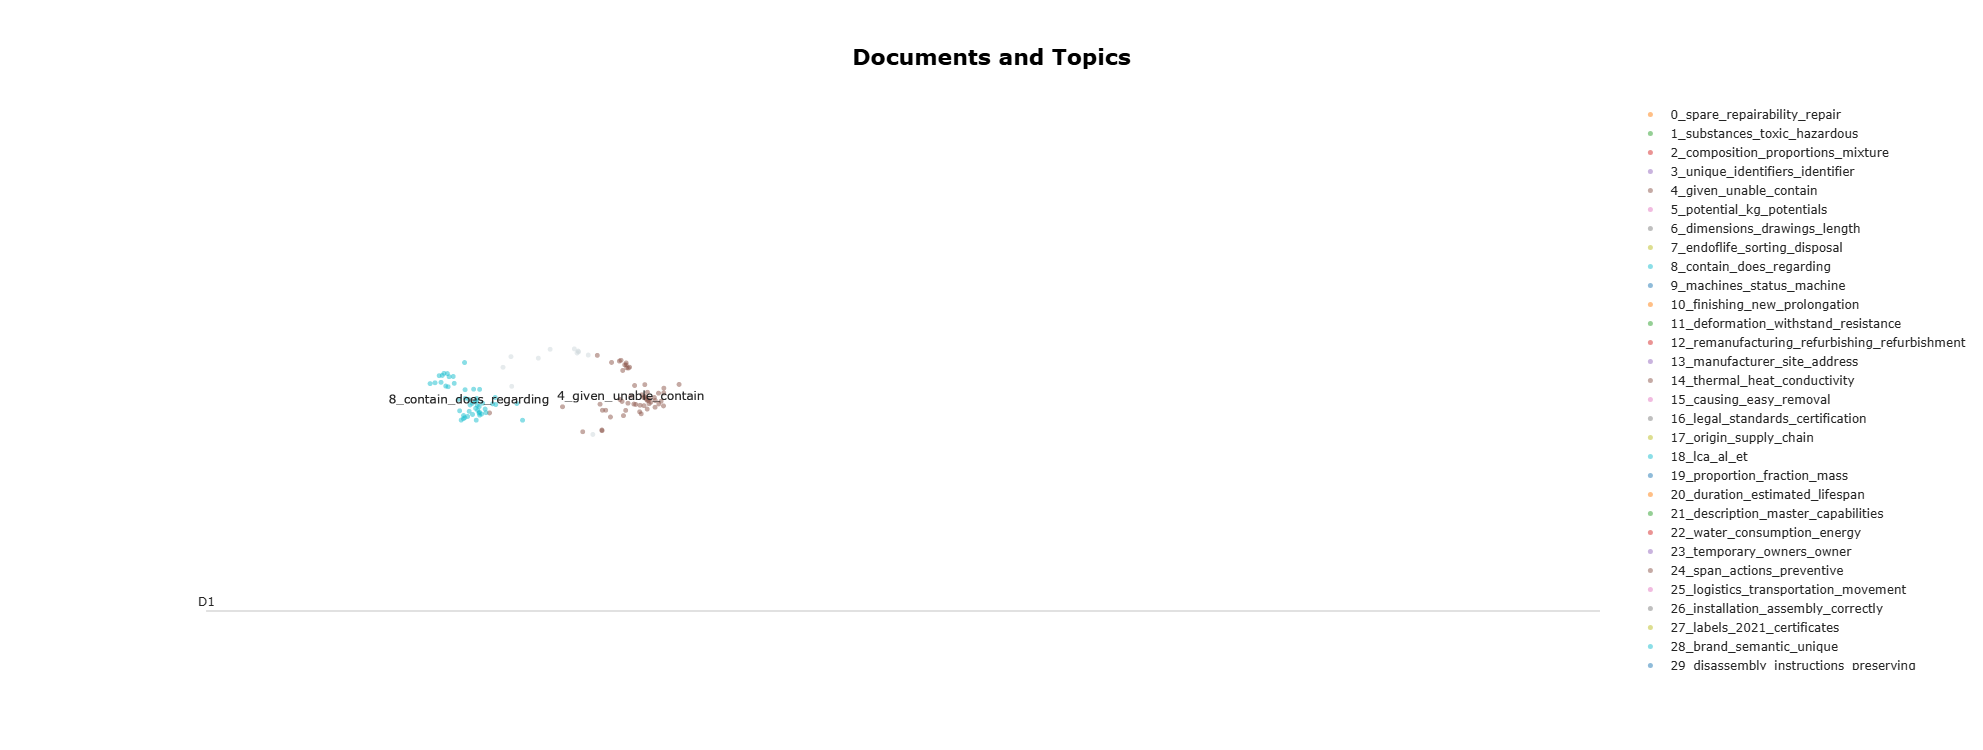

In [24]:
description_topic_model.visualize_documents(df["data_point"],  embeddings=description_embeddings)

In [26]:
# BERTopic has this built-in
from bertopic.dimensionality import BaseDimensionalityReduction

# Calculate coherence for the model trained on Names
coherence_names = description_topic_model.get_topic_coherence(method='c_v')


AttributeError: 'BERTopic' object has no attribute 'get_topic_coherence'

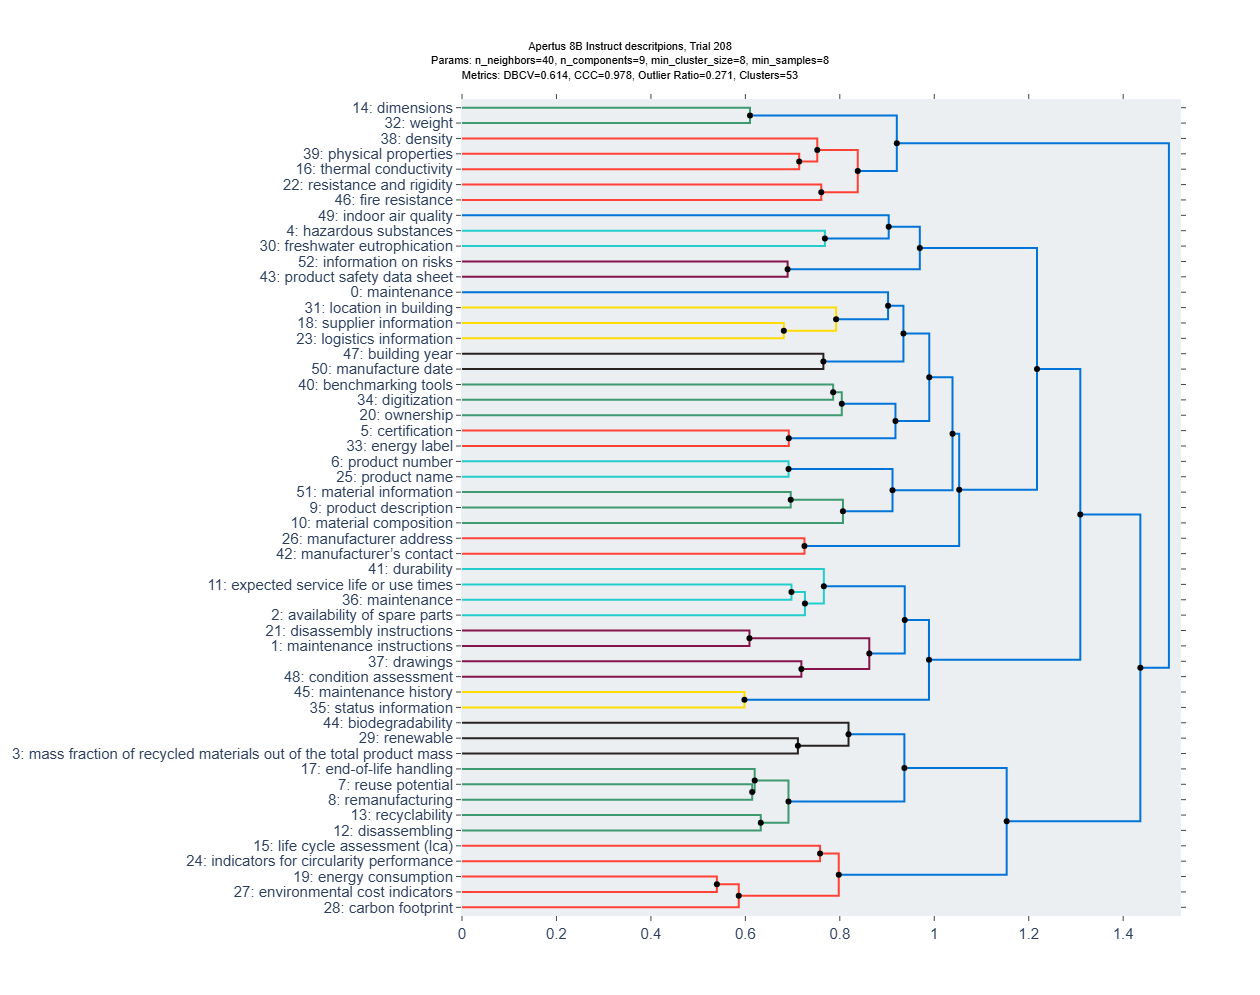

In [20]:
# Define a mapping from topic label -> custom hover text
custom_hover_map = {}
for v, k in zip(data_points_per_description_topic, label_per_description_topic):
    other_data_points = []
    for point in v['data_points']:
        if point['data_point'] in other_data_points:
            continue
        other_data_points.append(point['data_point'])
    
    custom_hover_map[k] = ";<br>".join(other_data_points[1:6])

fig_hierarchy.update_layout(
    hoverlabel=dict(
        align='left',   # moves text inside hover box to the right
        bgcolor="white",
        font_size=12,
        font_family="Arial"
    )
)

for trace in fig_hierarchy.data:
    if hasattr(trace, "text") and trace.text is not None:
        trace.hovertext = [
            f"<span style='display:inline-block; width:100px'></span>{custom_hover_map.get(t, t)}"
            for t in trace.text
        ]
        #trace.hovertemplate = "%{hovertext}<extra></extra>"  # clean hover box


# Save or show the updated plot
fig_hierarchy.show()


In [12]:
from pprint import pprint

def build_nested_dict(start, tree, hier_topics):
    """
    Convert a hierarchical tree into a nested dictionary.
    
    Parameters:
    - start: root node
    - tree: dict mapping parent -> list of children
    - hier_topics: DataFrame with hierarchical info (optional, used for distances)
    
    Returns:
    - nested dictionary representing the tree
    """
    
    def _build(parent):
        # If parent has no children, return empty dict
        if parent not in tree:
            return {}
        
        children = tree[parent]
        nested = {}
        
        for child in children:
            nested[child] = _build(child)
        
        return nested
    
    return {start: _build(start)}


tree = {
    str(linkage_matrix.shape[0] + row): [
        str(linkage_matrix[row, 0]),
        str(linkage_matrix[row, 1]),
    ]
    for row in range(linkage_matrix.shape[0])
}


pprint(build_nested_dict(str(linkage_matrix.shape[0] * 2 - 1), tree, hierarchical_topics))

{'91': {'87.0': {}, '91.0': {}}}


In [48]:
description_topic_model.get_topic_info().iloc[20].Representation         

['weight',
 'quantity',
 'pattern',
 'numerical',
 'gwp',
 'interoperable',
 'scalable',
 'suited',
 'attributes',
 'gravity']

In [42]:
from pprint import pprint
from scipy.cluster.hierarchy import linkage, to_tree


def build_tree_dict(node):
    if node.is_leaf():
        return {
            "0_topic_id": node.id,
            "1_topic_name": str(description_topic_model.get_topic_info().CustomName[description_topic_model.get_topic_info().Topic.astype(int) == node.id].iloc[0]),
            "2_data_points": list(set([p['data_point'] + " (" + p['original_source'] + ")" for p in data_points_per_description_topic[node.id + 1]['data_points']]))
        }
    return {
        "0_topic_id": node.id,
        "1_topic_name": str(hierarchical_topics.Parent_Name[hierarchical_topics.Parent_ID.astype(int) == node.id].iloc[0]),
        "2_children": [build_tree_dict(node.left),build_tree_dict(node.right)]
    }


root, nodes = to_tree(linkage_matrix, rd=True)

tree_dict = build_tree_dict(root)

with open(f"./results/Phi-4-mini/251113_grouped_datapoints_trial_{int(descriptions_trials_data.iloc[i]['number'])}_Phi-4-mini.json", "w") as f:
        json.dump(tree_dict, f, indent=4)
    
pprint(tree_dict)

{'0_topic_id': 118,
 '1_topic_name': 'instructions_ability_ensuring_provided_safety',
 '2_children': [{'0_topic_id': 115,
                 '1_topic_name': 'carbon_sustainability_footprint_reducing_consumption',
                 '2_children': [{'0_topic_id': 90,
                                 '1_topic_name': 'carbon_footprint_lca_water_al',
                                 '2_children': [{'0_topic_id': 14,
                                                 '1_topic_name': '14: life '
                                                                 'cycle '
                                                                 'assessment '
                                                                 '(lca)',
                                                 '2_data_points': ['acidification '
                                                                   'potential '
                                                                   '(ap) '
                                              

In [20]:
linkage_matrix

array([[ 25.        ,  18.        ,   0.57918583,   2.        ],
       [  5.        ,  55.        ,   0.58818242,   2.        ],
       [ 32.        ,  60.        ,   0.59722779,   3.        ],
       [ 24.        ,  12.        ,   0.60082476,   2.        ],
       [ 34.        ,  53.        ,   0.60299018,   2.        ],
       [ 20.        ,   8.        ,   0.60638466,   2.        ],
       [  6.        ,  19.        ,   0.62094178,   2.        ],
       [ 65.        ,   4.        ,   0.62529701,   3.        ],
       [ 10.        ,  47.        ,   0.62651376,   2.        ],
       [ 23.        ,  57.        ,   0.62978604,   2.        ],
       [  2.        ,   7.        ,   0.63175267,   2.        ],
       [ 31.        ,  16.        ,   0.6481574 ,   2.        ],
       [ 28.        ,  69.        ,   0.65052302,   3.        ],
       [ 30.        ,   9.        ,   0.6535169 ,   2.        ],
       [ 15.        ,  27.        ,   0.66733306,   2.        ],
       [ 13.        ,   1

{'icoord': [[5.0, 5.0, 15.0, 15.0],
  [25.0, 25.0, 35.0, 35.0],
  [30.0, 30.0, 45.0, 45.0],
  [10.0, 10.0, 37.5, 37.5],
  [75.0, 75.0, 85.0, 85.0],
  [80.0, 80.0, 95.0, 95.0],
  [65.0, 65.0, 87.5, 87.5],
  [55.0, 55.0, 76.25, 76.25],
  [105.0, 105.0, 115.0, 115.0],
  [125.0, 125.0, 135.0, 135.0],
  [110.0, 110.0, 130.0, 130.0],
  [145.0, 145.0, 155.0, 155.0],
  [120.0, 120.0, 150.0, 150.0],
  [65.625, 65.625, 135.0, 135.0],
  [165.0, 165.0, 175.0, 175.0],
  [185.0, 185.0, 195.0, 195.0],
  [190.0, 190.0, 205.0, 205.0],
  [170.0, 170.0, 197.5, 197.5],
  [215.0, 215.0, 225.0, 225.0],
  [183.75, 183.75, 220.0, 220.0],
  [100.3125, 100.3125, 201.875, 201.875],
  [245.0, 245.0, 255.0, 255.0],
  [235.0, 235.0, 250.0, 250.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [265.0, 265.0, 282.5, 282.5],
  [305.0, 305.0, 315.0, 315.0],
  [273.75, 273.75, 310.0, 310.0],
  [291.875, 291.875, 325.0, 325.0],
  [242.5, 242.5, 308.4375, 308.4375],
  [151.09375, 151.09375, 275.46875, 

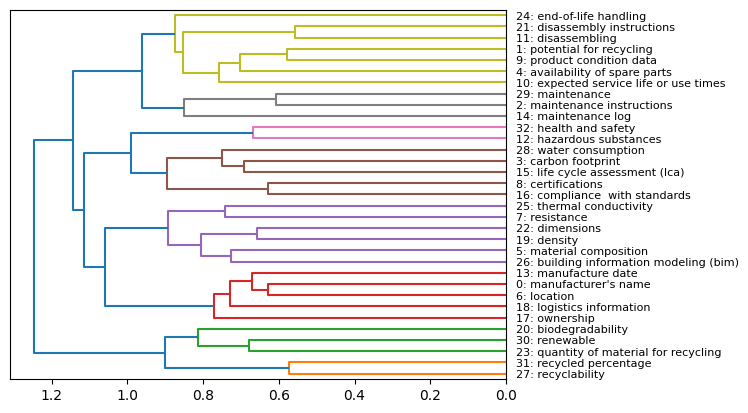

In [48]:
sch.dendrogram(
        linkage_matrix,
        orientation="left",
        labels=label_per_description_topic[description_topic_model._outliers:],
        no_plot=False,
        color_threshold=color_threshold,
    )